# Hierarchical Clustering

            ## 1. Learning objectives

            - Explain agglomerative merging
- Implement single linkage
- Read a dendrogram and compare linkage rules

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Build a nested hierarchy of groups rather than committing immediately to one flat partition.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            Begin with one cluster per observation and repeatedly join the two closest clusters; the full merge history forms a tree.

## 6. Mathematical foundation

            $$D_{single}(A,B)=\min_{\mathbf{x}\in A,\mathbf{y}\in B}d(\mathbf{x},\mathbf{y}).$$

            **Every symbol:**

            - $A$ and $B$ are clusters.
- $\mathbf{x}$ and $\mathbf{y}$ are member observations.
- $d$ is point distance.
- $D_{single}$ is the closest cross-cluster distance.

            **Why the equation is needed:** A linkage rule defines what closest clusters means.

            **Small numerical example:** If cross-cluster distances are 2, 5, 7, and 9, single linkage uses 2.

            **Connection to Python:** cdist(X[A], X[B]).min() is the direct translation.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
from scipy.spatial.distance import cdist

def single_linkage_scratch(features, target_clusters):
    clusters = [[index] for index in range(len(features))]
    while len(clusters) > target_clusters:
        best = (np.inf, 0, 1)
        for left in range(len(clusters)):
            for right in range(left + 1, len(clusters)):
                distance = cdist(features[clusters[left]], features[clusters[right]]).min()
                if distance < best[0]:
                    best = (distance, left, right)
        _, left, right = best
        clusters[left] = clusters[left] + clusters[right]
        clusters.pop(right)
    labels = np.empty(len(features), dtype=int)
    for cluster_id, members in enumerate(clusters):
        labels[members] = cluster_id
    return labels

tiny = np.array([[0., 0.], [.2, .1], [4., 4.], [4.2, 4.1]])
print("Tiny single-link labels:", single_linkage_scratch(tiny, 2))

Tiny single-link labels: [0 0 1 1]


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Scratch/library ARI: 1.0
Silhouette: 0.882


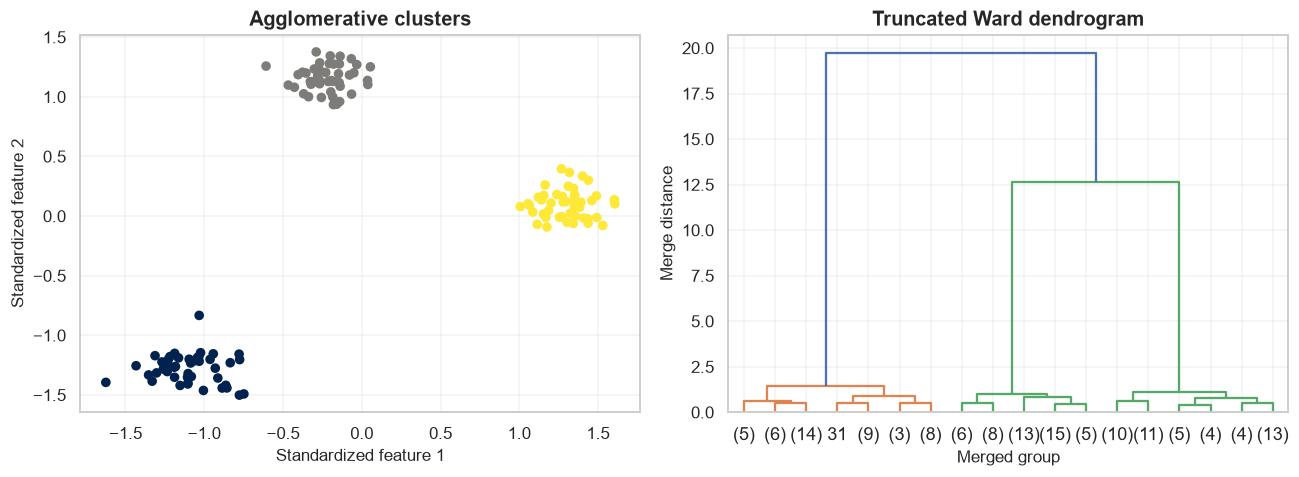

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X, hidden_labels = make_blobs(n_samples=140, centers=3, cluster_std=.75, random_state=RANDOM_SEED)
X_scaled = StandardScaler().fit_transform(X)
scratch_labels = single_linkage_scratch(X_scaled, 3)
model = AgglomerativeClustering(n_clusters=3, linkage="single").fit(X_scaled)
print("Scratch/library ARI:", round(adjusted_rand_score(scratch_labels, model.labels_), 3))
print("Silhouette:", round(silhouette_score(X_scaled, model.labels_), 3))

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap="cividis", s=28)
axes[0].set(title="Agglomerative clusters", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
dendrogram(linkage(X_scaled, method="ward"), truncate_mode="lastp", p=18, ax=axes[1], color_threshold=None)
axes[1].set(title="Truncated Ward dendrogram", xlabel="Merged group", ylabel="Merge distance")
figure.tight_layout()
plt.show()

**How to interpret the result:** The scatter plot shows one cut; the dendrogram retains the larger hierarchy and merge distances.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Single, complete, average, and Ward linkage make different geometric assumptions.

,linkage,silhouette
0,single,0.882
1,complete,0.882
2,average,0.882
3,ward,0.882


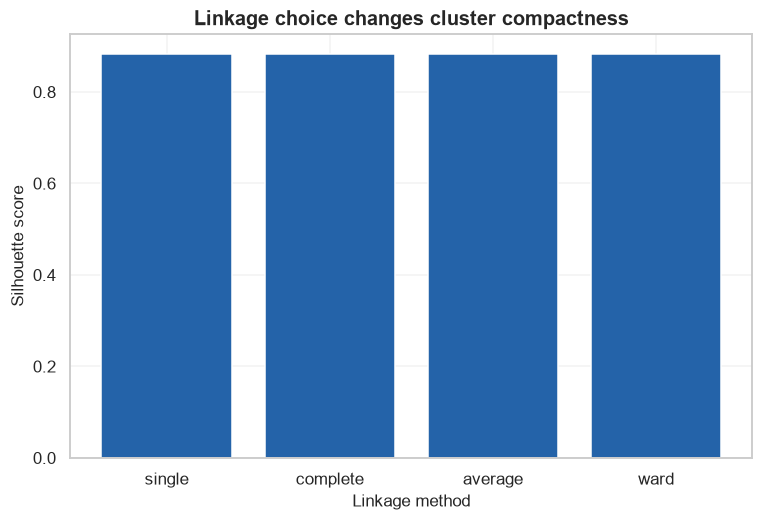

In [4]:
rows = []
for linkage_name in ["single", "complete", "average", "ward"]:
    labels = AgglomerativeClustering(n_clusters=3, linkage=linkage_name).fit_predict(X_scaled)
    rows.append({"linkage": linkage_name, "silhouette": silhouette_score(X_scaled, labels)})
comparison = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
display(comparison.round(3))
figure, axis = plt.subplots()
axis.bar(comparison["linkage"], comparison["silhouette"], color=COURSE_COLORS["blue"])
axis.set(title="Linkage choice changes cluster compactness", xlabel="Linkage method", ylabel="Silhouette score")
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Does not require labels
- Can expose previously unknown structure

            **Disadvantages**

            - Evaluation is indirect
- Results can be sensitive to representation and hyperparameters

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can single linkage create chains?
2. **Mathematical/hand calculation:** Given cross-distances [2, 4, 6], find single and complete linkage.
3. **Coding/experimentation:** Change the dendrogram cut and compare the number of groups.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. One close pair can connect two otherwise distant groups, and repeated bridges form a chain.
2. Single is 2; complete is 6.
3. Choose a horizontal cut, count intersected branches, then check stability and domain usefulness.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html)